In [23]:
# Import Necessary Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score
import xgboost as xgb
from imblearn.over_sampling import SMOTE

In [5]:
# Load The Dataset
df = pd.read_csv('creditcard.csv')

In [10]:
# Dataset Information 
print("Dataset Information")
print(df.head())
print(df['Class'].value_counts())

Dataset Information
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26 

In [11]:
# Check Missing Values
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [14]:
# Define Feature and Targets
X = df.drop(columns='Class',axis=1)
y = df['Class']

In [33]:
#Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [34]:
# Feature Scaling (Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
#Handle Imbalance Data (Using SMOTE)
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled,y_train)

In [36]:
#Train the model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_sm,y_train_sm)

re = RandomForestClassifier(n_estimators=100,random_state=42)
re.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [37]:
#Predict the model
y_pred_lr = lr.predict(X_test_scaled)
y_pred_re = re.predict(X_test)

In [38]:
#Evaluate Regression Model
print("Regression Accuracy:",accuracy_score(y_test,y_pred_lr))
print("\nClassification Report\n",classification_report(y_test,y_pred_lr))
print("\nROC-AUC Score",roc_auc_score(y_test,lr.predict_proba(X_test_scaled)[:,1]))

Regression Accuracy: 0.9741055440469084

Classification Report
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


ROC-AUC Score 0.9708434302252134


In [39]:
#Evaluate Random Forest Model
print("Random Forest Accuracy:",accuracy_score(y_test,y_pred_re))
print("\nClassification Report\n",classification_report(y_test,y_pred_re))
print("\nROC-AUC Score",roc_auc_score(y_test,re.predict_proba(X_test)[:,1]))

Random Forest Accuracy: 0.9995962220427653

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC Score 0.9630272515590367


Text(0.5, 1.0, 'Confusion Matrix - Logistic Regression')

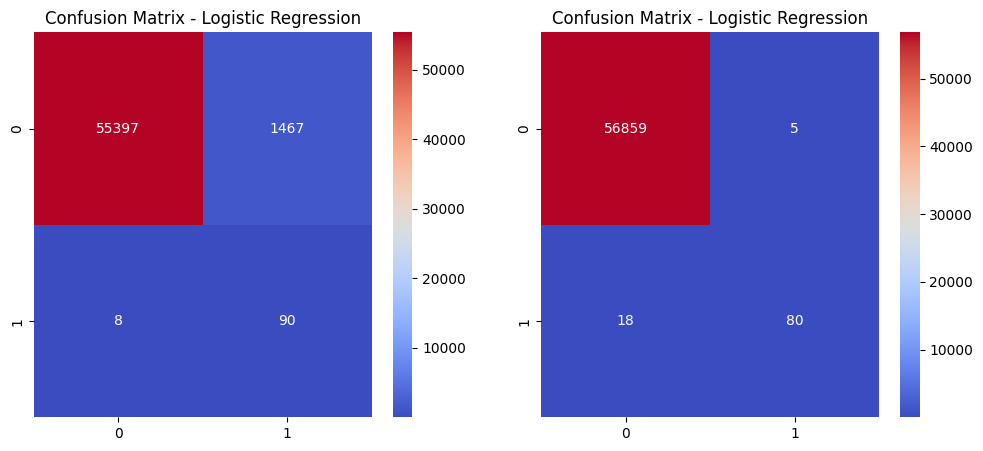

In [50]:
fig, ax = plt.subplots(1,2,figsize=(12,5))
sns.heatmap(confusion_matrix(y_test,y_pred_lr),annot=True, fmt='d', cmap='coolwarm', ax=ax[0])
ax[0].set_title("Confusion Matrix - Logistic Regression")

sns.heatmap(confusion_matrix(y_test,y_pred_re),annot=True, fmt='d', cmap='coolwarm', ax=ax[1])
ax[1].set_title("Confusion Matrix - Logistic Regression")
